In [1]:
# Parameters
frequency = "1d"
window_pred = 1


In [2]:
import numpy as np
import pandas as pd
from pylab import plt
from tqdm import tqdm
from sklearn.metrics import accuracy_score, f1_score
import os
import talib as ta
import optuna
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.utils.class_weight import compute_sample_weight

# Frecuencia obtenida desde el main
try:
    print(f"Frecuencia recibida desde papermill: {frequency}")
except NameError:
    print(f"No se recibió 'frequency'.")


# Cargar los datos para esta frecuencia de un archivo creado por el main
file_name = f"processed_data_{frequency}_charac.csv"
data = pd.read_csv(file_name, index_col='timestamp')
data


Frecuencia recibida desde papermill: 1d


C:\Users\Usuario\AppData\Roaming\Python\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,BTCUSDT_1d,ETHUSDT_1d,XRPUSDT_1d,BNBUSDT_1d,SOLUSDT_1d,ADAUSDT_1d,TRXUSDT_1d,LINKUSDT_1d,AVAXUSDT_1d
timestamp,,,,,,,,,
2020-09-22,10529.61,344.21,0.23302,24.0468,2.9082,0.08146,0.02499,8.7401,5.3193
2020-09-23,10241.46,320.72,0.22164,22.8331,2.8548,0.07663,0.02486,7.6364,3.5350
2020-09-24,10736.32,348.97,0.23276,24.5745,3.1433,0.08254,0.02625,9.8700,4.6411
2020-09-25,10686.67,351.92,0.24154,24.6924,3.1937,0.09693,0.02714,10.7279,4.7134
2020-09-26,10728.60,353.92,0.24153,26.1998,3.1287,0.09547,0.02718,10.3169,4.5200
...,...,...,...,...,...,...,...,...,...
2024-12-28,95300.00,3404.00,2.18430,722.1300,195.5000,0.88950,0.25840,21.9900,37.7400
2024-12-29,93738.20,3356.48,2.09420,694.7100,189.9400,0.85900,0.25780,20.9600,35.8400
2024-12-30,92792.05,3361.84,2.05870,705.3600,191.3800,0.86150,0.25340,20.5800,35.9700


Función para guardar los datos. Hace un archivo por cada frecuencia. Guarda en cada línea el modelo que se ha empleado, el activo, accuracy e in/out-sample.

In [3]:
def save_results(model, ric, acc, sample, frequency=frequency):
    # Verificar si el archivo ya existe
    file_name = f'accuracy_results_{frequency}_charac.csv'

    # Si el archivo existe, leer los datos previos, si no, crear un nuevo DataFrame vacío
    if os.path.exists(file_name):
        df_results = pd.read_csv(file_name)
    else:
        df_results = pd.DataFrame(columns=['Model', 'Asset', 'Accuracy', 'What'])

    # Agregar la nueva fila con los resultados
    new_row = pd.DataFrame([[model, ric, acc, sample]], columns=['Model', 'Asset', 'Accuracy', 'What'])
    df_results = pd.concat([df_results, new_row], ignore_index=True)

    # Guardar los resultados acumulados
    df_results.to_csv(file_name, index=False) 

Creamos las características que usaremos para hacer el aprendizaje ahora y las retardamos.

In [4]:
def charact_lags(data, ric, lags, window_pred, window=30):
    cols = []
    df = pd.DataFrame(data[ric])
    df['r'] = np.log(df / df.shift()) #retornos
    df['sma'] = df[ric].rolling(window).mean()  #media movil de la ventana
    df['min'] = df[ric].rolling(window).min() #mínimo de la ventana
    df['max'] = df[ric].rolling(window).max() #máximo de la ventana
    df['mom'] = df[ric].pct_change(window) #momentum de la ventana pct_change(12)
    df['vol'] = df['r'].rolling(window).std() #volatilidad de la ventana
    df['rsi'] = ta.RSI(df[ric], timeperiod=window) #rsi de la ventana
    df['atr'] = ta.ATR(df[ric], df[ric], df[ric], timeperiod=window) #atr de la ventana
    df = df.iloc[:-window_pred]
    df['d'] = np.where(df[ric].shift(-window_pred) > df[ric], 1, 0) # columna binaria, 0 si los precios bajarán, 1 si subirán
    features = [ric, 'r', 'sma', 'min', 'max', 'mom', 'vol', 'rsi', 'atr']
    for f in features:
        for lag in range(1, lags + 1):
            col = f'{f}_lag_{lag}'
            df[col] = df[f].shift(lag)
            cols.append(col)
    return df, cols

lags = 5

dfs = {}
results = []
for ric in data:
    df, cols = charact_lags(data, ric, lags, window_pred)
    dfs[ric] = df, cols
    p = df['d'].value_counts(normalize=True) 
    results.append({
        'ric': ric,
        '0': p[0],
        '1': p[1]}
        )
results_df = pd.DataFrame(results)
results_df 

,ric,0,1
0,BTCUSDT_1d,0.494238,0.505762
1,ETHUSDT_1d,0.478873,0.521127
2,XRPUSDT_1d,0.492318,0.507682
3,BNBUSDT_1d,0.476312,0.523688
4,SOLUSDT_1d,0.498720,0.501280
5,ADAUSDT_1d,0.501280,0.498720
6,TRXUSDT_1d,0.460948,0.539052
7,LINKUSDT_1d,0.483355,0.516645
8,AVAXUSDT_1d,0.503201,0.496799


In [5]:
def normalize_with_close(X, close_col):
    """
    Normaliza columnas ratio en función del precio de cierre.
    """
    ratio_cols = [col for col in X.columns if any(x in col for x in ['sma','atr','min','max'])]
    for col in ratio_cols:
        X[col] = X[col] / close_col
    return X

# ---------------------------------------------------
def prepare_features(df):
    """
    One-hot encoding de la columna 'crypto'.
    """
    crypto_dummies = pd.get_dummies(df['crypto'], prefix='crypto')
    X = pd.concat([df.drop(columns=['crypto']), crypto_dummies], axis=1)
    return X, crypto_dummies.columns

# ---------------------------------------------------

In [6]:
def walk_forward_fit_test(model_class, freq, model_params={}, n_trials=5, search_space=None, data=data):
    if freq == '1h':
        period = pd.Timedelta(days=7)
    elif freq == '4h':
        period = pd.Timedelta(days=15)
    else:
        period = pd.Timedelta(days=90)
    final_test_period = pd.Timedelta(days=365)

    def suggest_params(trial):
        trial_params = {}
        for param_name, param_info in search_space.items():
            if param_info['type'] == 'int':
                trial_params[param_name] = trial.suggest_int(param_name, *param_info['bounds'])
            elif param_info['type'] == 'float':
                trial_params[param_name] = trial.suggest_float(param_name, *param_info['bounds'], log=param_info.get('log', False))
            elif param_info['type'] == 'categorical':
                trial_params[param_name] = trial.suggest_categorical(param_name, param_info['choices'])
        trial_params.update(model_params)
        return trial_params

    ric_best_params = {}
    desb_graf = []
    df_res = None

    for ric in data:
        df, cols = data[ric]
        df = df[cols + ['d']].copy()
        df.dropna(inplace=True)
        df['timestamp'] = pd.to_datetime(df.index)
        max_time = df['timestamp'].max()
        cutoff = max_time - final_test_period
        df_trainval = df[df['timestamp'] < cutoff].copy()

        # Generar fechas de split
        min_time = df_trainval['timestamp'].min()
        split_dates = []
        current_time = min_time + period
        while current_time < cutoff:
            split_dates.append(current_time)
            current_time += period
        split_dates = split_dates[-5:]

        def objective(trial):
            trial_params = suggest_params(trial)
            resul_acc = []
            resul_f1 = []

            for split_date in split_dates:
                train = df_trainval[df_trainval['timestamp'] < (split_date - pd.Timedelta(days=window_pred))]
                test = df_trainval[(df_trainval['timestamp'] >= split_date) & (df_trainval['timestamp'] < split_date + period)]
                if len(test) == 0:
                    continue

                X_train, y_train = train.drop(columns=['d', 'timestamp']), train['d']
                X_test, y_test = test.drop(columns=['d', 'timestamp']), test['d']
                X_train = normalize_with_close(X_train.copy(), train[f'{ric}_lag_1'])
                X_test = normalize_with_close(X_test.copy(), test[f'{ric}_lag_1'])

                model = model_class(**trial_params)
                if model_class.__name__ == 'MLPClassifier':
                    X_train = X_train.loc[:, ~X_train.columns.str.contains(ric)]
                    X_test = X_test.loc[:, ~X_test.columns.str.contains(ric)]
                    model.fit(X_train, y_train)
                else:
                    weights = compute_sample_weight(class_weight='balanced', y=y_train)
                    X_train = X_train.loc[:, ~X_train.columns.str.contains(ric)]
                    X_test = X_test.loc[:, ~X_test.columns.str.contains(ric)]
                    model.fit(X_train, y_train, sample_weight=weights)

                pred = np.where(model.predict(X_test) > 0.5, 1, 0)
                f1 = f1_score(y_test, pred, average='macro')
                acc = accuracy_score(y_test, pred)
                resul_acc.append(acc)
                resul_f1.append(f1)

            avg_f1 = np.mean(resul_f1)
            avg_acc = np.mean(resul_acc)
            dist_true = y_test.value_counts(normalize=True).to_dict()
            dist_pred = pd.Series(pred).value_counts(normalize=True).to_dict()
            print(f'VALIDATION |  {ric:7s} | avg_acc={avg_acc:.4f} | avg_f1={avg_f1:.4f}')
            save_results(model_class.__name__, ric, avg_f1, 'F1 VALIDATION', frequency=freq)
            print(f"    Desbalanceo reales (val)      : {dist_true}")
            print(f"    Desbalanceo predicciones (val): {dist_pred}")
            save_results(model_class.__name__, ric, dist_true, 'DESBALANCEO REAL VAL', frequency=freq)
            save_results(model_class.__name__, ric, dist_pred, 'DESBALANCEO PREDICCIÓN VAL', frequency=freq)
            return avg_f1

        study = optuna.create_study(direction="maximize")
        study.optimize(objective, n_trials=n_trials, n_jobs=1)

        best_params = study.best_params
        ric_best_params[ric] = best_params
        print(f"Mejores parámetros para {ric}: {best_params}")

        # Test final con los mejores parámetros
        df_test = df[df['timestamp'] >= cutoff].copy()
        train = df[df['timestamp'] < (cutoff - pd.Timedelta(days=window_pred))]
        test = df_test

        if len(test) == 0:
            continue

        X_train, y_train = train.drop(columns=['d', 'timestamp']), train['d']
        X_test, y_test = test.drop(columns=['d', 'timestamp']), test['d']

        X_train = normalize_with_close(X_train.copy(), train[f'{ric}_lag_1'])
        X_test = normalize_with_close(X_test.copy(), test[f'{ric}_lag_1'])

        model = model_class(**best_params)
        if model_class.__name__ == 'MLPClassifier':
            X_train = X_train.loc[:, ~X_train.columns.str.contains(ric)]
            X_test = X_test.loc[:, ~X_test.columns.str.contains(ric)]
            model.fit(X_train, y_train)
        else:
            weights = compute_sample_weight(class_weight='balanced', y=y_train)
            X_train = X_train.loc[:, ~X_train.columns.str.contains(ric)]
            X_test = X_test.loc[:, ~X_test.columns.str.contains(ric)]
            model.fit(X_train, y_train, sample_weight=weights)

        pred = np.where(model.predict(X_test) > 0.5, 1, 0)
        df_res = pd.DataFrame({'true': y_test, 'pred': pred})
        acc = accuracy_score(y_test, pred)
        f1 = f1_score(y_test, pred, average='macro')
        dist_true = y_test.value_counts(normalize=True).to_dict()
        dist_pred = pd.Series(pred).value_counts(normalize=True).to_dict()
        real_0 = dist_true.get(0, 0)
        real_1 = dist_true.get(1, 0)
        pred_0 = dist_pred.get(0, 0)
        pred_1 = dist_pred.get(1, 0)

        desb_graf.append({
            "cripto": ric,
            "acc": acc,
            "f1": f1,
            "real_0": real_0,
            "real_1": real_1,
            "pred_0": pred_0,
            "pred_1": pred_1
        })
        print(f'FINAL TEST | {ric:7s} | acc={acc:.4f} | f1={f1:.4f}')
        print(f"    Desbalanceo reales      : {dist_true}")
        print(f"    Desbalanceo predicciones: {dist_pred}")
        save_results(model_class.__name__, ric, acc, 'FINAL TEST', frequency=freq)
        save_results(model_class.__name__, ric, f1, 'F1 FINAL TEST', frequency=freq)
        save_results(model_class.__name__, ric, dist_true, 'DESBALANCEO REAL', frequency=freq)
        save_results(model_class.__name__, ric, dist_pred, 'DESBALANCEO PREDICCIÓN', frequency=freq)

        if model_class.__name__ != 'MLPClassifier':
            df_weights = pd.DataFrame({'y': y_train, 'weight': weights})
            avg_weights = df_weights.groupby('y')['weight'].mean().to_dict()
            print(f"    Pesos promedio entrenamiento: {avg_weights}")

    return ric_best_params, desb_graf, df_res


In [7]:
# === Definición del espacio de búsqueda para cada modelo ===

search_spaces = {
    "MLPClassifier": {
        "hidden_layer_sizes": {"type": "int",   "bounds": (32, 1024), "step": 32},
        "alpha":              {"type": "float", "bounds": (1e-6, 1e-1), "log": True},
        "learning_rate_init": {"type": "float", "bounds": (1e-5, 1e-1), "log": True},
    },
    "RandomForestClassifier": {
        "n_estimators":      {"type": "int",         "bounds": (100, 1000), "step": 100},
        "max_depth":         {"type": "int",         "bounds": (3,   30)},
        "min_samples_split": {"type": "int",         "bounds": (2,   10)},
        "min_samples_leaf":  {"type": "int",         "bounds": (1,   10)},
        "max_features":      {"type": "categorical", "choices": ["sqrt", "log2", None]},
        "bootstrap":         {"type": "categorical", "choices": [True, False]},
    },
    "GradientBoostingClassifier": {
        "n_estimators":      {"type": "int",   "bounds": (50, 500),  "step": 50},
        "learning_rate":     {"type": "float", "bounds": (1e-3, 0.3), "log": True},
        "max_depth":         {"type": "int",   "bounds": (3,   15)},
        "min_samples_split": {"type": "int",   "bounds": (2,   20)},
        "min_samples_leaf":  {"type": "int",   "bounds": (1,   20)},
    },
}

# === Parámetros fijos para cada modelo ===

model_fixed_params = {
    "MLPClassifier": {
        "max_iter": 1000,
        "early_stopping": True,
        "validation_fraction": 0.15,
        "shuffle": False,
        "random_state": 100,
    },
    "RandomForestClassifier": {
        "random_state": 100,
        "n_jobs": -1
    },
    "GradientBoostingClassifier": {
        "random_state": 100
    }
}

# === Diccionario de clases de modelos ===

model_classes = {
    "MLPClassifier": MLPClassifier,
    "RandomForestClassifier": RandomForestClassifier,
    "GradientBoostingClassifier": GradientBoostingClassifier
}

# === Entrenamiento en bucle ===

best_params_dict = {}
desb_graf_dict = {}
data_graf_dict = {}

for model_name, model_cls in model_classes.items():
    print(f"\n\n=== Entrenando modelo: {model_name} ===\n")
    
    best_params, desb_graf, df_res = walk_forward_fit_test(
        model_class=model_cls,
        freq=frequency,
        search_space=search_spaces[model_name],
        model_params=model_fixed_params.get(model_name, {}),
        n_trials=1,
        data=dfs  
    )

    best_params_dict[model_name] = best_params
    desb_graf_dict[model_name] = desb_graf
    data_graf_dict[model_name] = df_res

print("\n\n=== Mejores hiperparámetros por modelo ===")
for model_name, params in best_params_dict.items():
    print(f"{model_name}: {params}")


[I 2025-06-13 01:15:12,120] A new study created in memory with name: no-name-dfbd9142-0df1-46e5-8655-94827cb7bf5f




=== Entrenando modelo: MLPClassifier ===



C:\Users\Usuario\AppData\Local\Temp\ipykernel_23432\2570594645.py:13: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  df_results = pd.concat([df_results, new_row], ignore_index=True)
[I 2025-06-13 01:15:12,497] Trial 0 finished with value: 0.32880708604473374 and parameters: {'hidden_layer_sizes': 235, 'alpha': 0.0007334119646169241, 'learning_rate_init': 0.03348969596295813}. Best is trial 0 with value: 0.32880708604473374.


VALIDATION |  BTCUSDT_1d | avg_acc=0.4923 | avg_f1=0.3288
    Desbalanceo reales (val)      : {1: 0.6049382716049383, 0: 0.3950617283950617}
    Desbalanceo predicciones (val): {0: 1.0}
Mejores parámetros para BTCUSDT_1d: {'hidden_layer_sizes': 235, 'alpha': 0.0007334119646169241, 'learning_rate_init': 0.03348969596295813}


[I 2025-06-13 01:15:12,802] A new study created in memory with name: no-name-a84ade56-3b71-4a43-8097-fb01566dfa85


...

[I 2025-06-13 01:20:36,621] A new study created in memory with name: no-name-e6c945cd-8541-4198-9027-d887c2d26511


FINAL TEST | LINKUSDT_1d | acc=0.4781 | f1=0.4739
    Desbalanceo reales      : {0: 0.5109289617486339, 1: 0.4890710382513661}
    Desbalanceo predicciones: {0: 0.5792349726775956, 1: 0.4207650273224044}
    Pesos promedio entrenamiento: {0: 1.0507246376811594, 1: 0.9539473684210527}


[I 2025-06-13 01:20:50,617] Trial 0 finished with value: 0.5056526451821114 and parameters: {'n_estimators': 121, 'learning_rate': 0.0018762987136283665, 'max_depth': 14, 'min_samples_split': 11, 'min_samples_leaf': 13}. Best is trial 0 with value: 0.5056526451821114.


VALIDATION |  AVAXUSDT_1d | avg_acc=0.5151 | avg_f1=0.5057
    Desbalanceo reales (val)      : {1: 0.6790123456790124, 0: 0.32098765432098764}
    Desbalanceo predicciones (val): {1: 0.5802469135802469, 0: 0.41975308641975306}
Mejores parámetros para AVAXUSDT_1d: {'n_estimators': 121, 'learning_rate': 0.0018762987136283665, 'max_depth': 14, 'min_samples_split': 11, 'min_samples_leaf': 13}


FINAL TEST | AVAXUSDT_1d | acc=0.4836 | f1=0.4836
    Desbalanceo reales      : {0: 0.5382513661202186, 1: 0.46174863387978143}
    Desbalanceo predicciones: {1: 0.5300546448087432, 0: 0.46994535519125685}
    Pesos promedio entrenamiento: {0: 1.0193321616871704, 1: 0.9813874788494078}


=== Mejores hiperparámetros por modelo ===
MLPClassifier: {'BTCUSDT_1d': {'hidden_layer_sizes': 235, 'alpha': 0.0007334119646169241, 'learning_rate_init': 0.03348969596295813}, 'ETHUSDT_1d': {'hidden_layer_sizes': 665, 'alpha': 0.011094155821503, 'learning_rate_init': 1.6200838137963212e-05}, 'XRPUSDT_1d': {'hidden_layer_sizes': 572, 'alpha': 0.008999275584245296, 'learning_rate_init': 0.00039854281321009474}, 'BNBUSDT_1d': {'hidden_layer_sizes': 578, 'alpha': 1.145679931846167e-05, 'learning_rate_init': 0.008457842554814934}, 'SOLUSDT_1d': {'hidden_layer_sizes': 929, 'alpha': 1.2028451028975803e-06, 'learning_rate_init': 0.002236887853095876}, 'ADAUSDT_1d': {'hidden_layer_sizes': 540, 'alpha': 0.09864

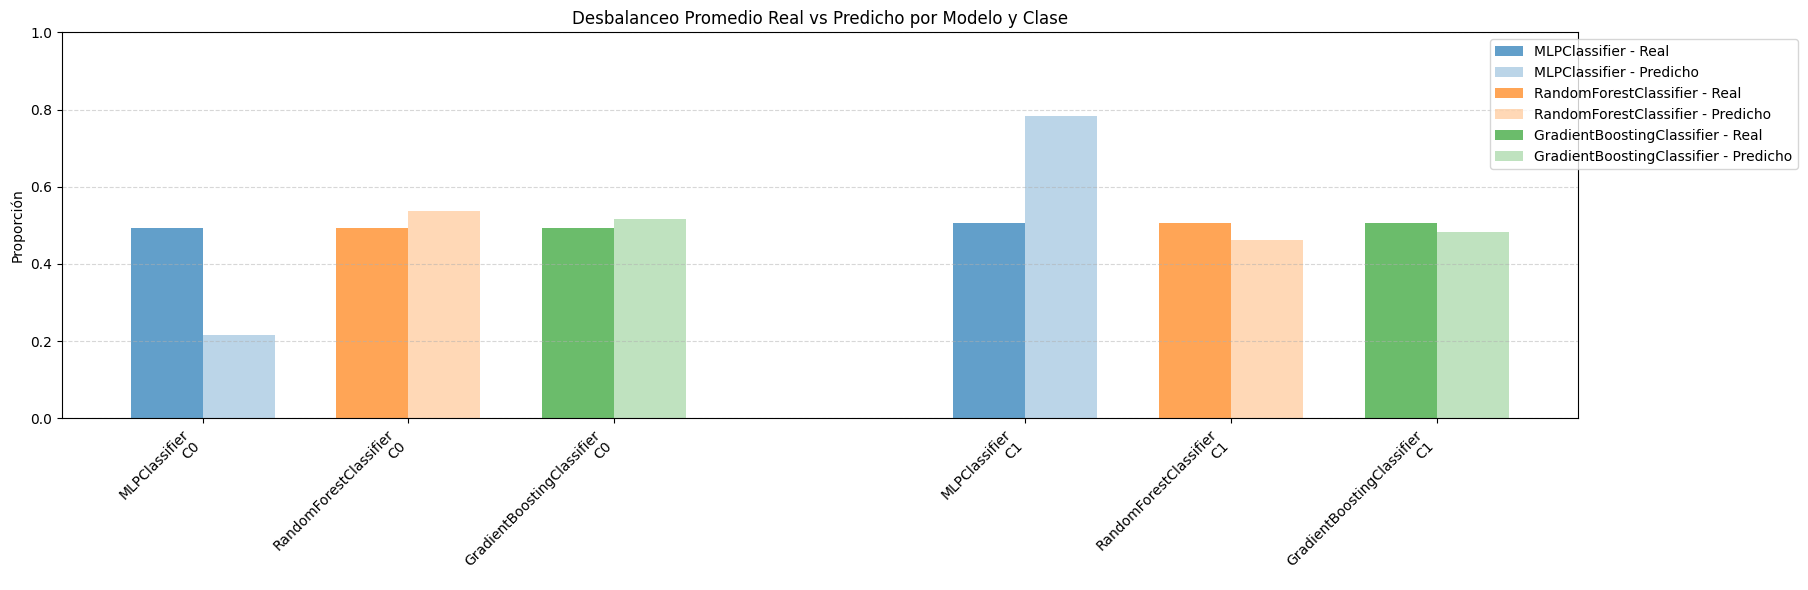

In [8]:
# Datos para el gráfico
model_names = list(desb_graf_dict.keys())
n_models = len(model_names)
bar_width = 0.35
spacing = 1.0  # espacio entre los grupos de clase 0 y clase 1

# Posiciones en el eje x
x_class_0 = np.arange(n_models)
x_class_1 = x_class_0 + n_models + spacing  # separado por un espacio

fig, ax = plt.subplots(figsize=(18, 6))

colors = plt.cm.tab10.colors  # paleta estándar de 10 colores

for idx, (model_name, data_graf) in enumerate(desb_graf_dict.items()):
    df = pd.DataFrame(data_graf)
    
    real_0 = df['real_0'].mean()
    pred_0 = df['pred_0'].mean()
    real_1 = df['real_1'].mean()
    pred_1 = df['pred_1'].mean()
    
    # barras clase 0
    ax.bar(x_class_0[idx], real_0, width=bar_width, label=f'{model_name} - Real', color=colors[idx], alpha=0.7)
    ax.bar(x_class_0[idx] + bar_width, pred_0, width=bar_width, label=f'{model_name} - Predicho', color=colors[idx], alpha=0.3)
    
    # barras clase 1
    ax.bar(x_class_1[idx], real_1, width=bar_width, color=colors[idx], alpha=0.7)
    ax.bar(x_class_1[idx] + bar_width, pred_1, width=bar_width, color=colors[idx], alpha=0.3)

# Etiquetas y ejes
ax.set_xticks(
    list(x_class_0 + bar_width / 2) + list(x_class_1 + bar_width / 2)
)
ax.set_xticklabels(
    [f'{name}\nC0' for name in model_names] + [f'{name}\nC1' for name in model_names],
    rotation=45, ha='right'
)
ax.set_ylabel('Proporción')
ax.set_title('Desbalanceo Promedio Real vs Predicho por Modelo y Clase')
ax.set_ylim(0, 1)
ax.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()


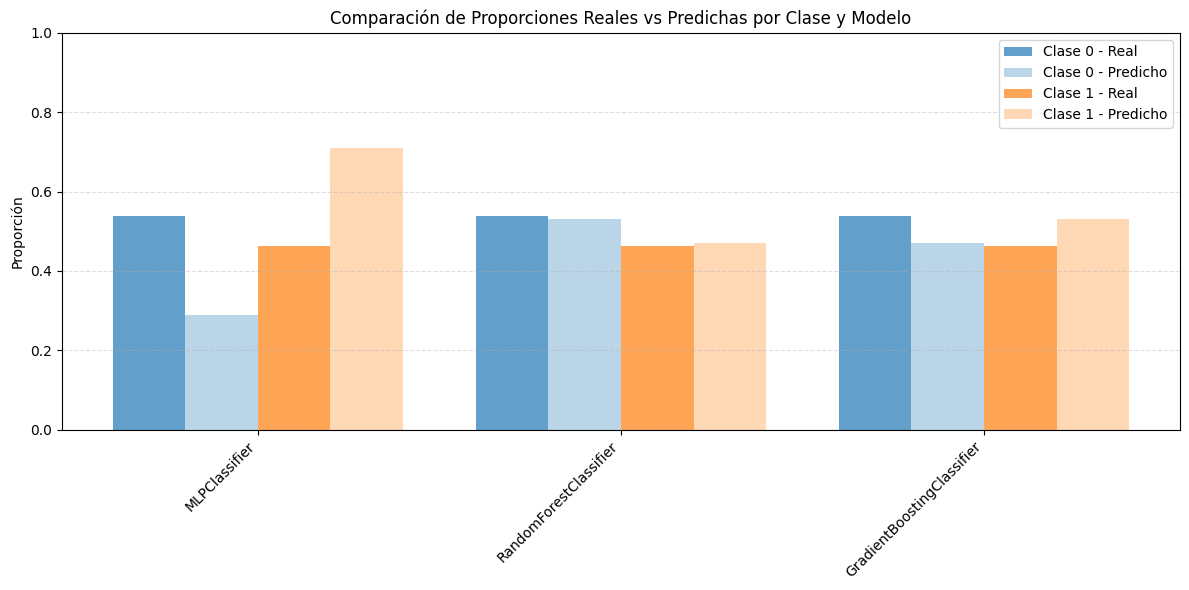

In [9]:
model_names = []
real_0, real_1, pred_0, pred_1 = [], [], [], []

for model, res in data_graf_dict.items():
    y_test = pd.Series(res["true"])
    y_pred = pd.Series(res["pred"])
    
    real_dist = y_test.value_counts(normalize=True).to_dict()
    pred_dist = y_pred.value_counts(normalize=True).to_dict()

    model_names.append(model)
    real_0.append(real_dist.get(0, 0))
    real_1.append(real_dist.get(1, 0))
    pred_0.append(pred_dist.get(0, 0))
    pred_1.append(pred_dist.get(1, 0))

# Posiciones para las barras
x = np.arange(len(model_names))
bar_width = 0.2

# Crear gráfico
fig, ax = plt.subplots(figsize=(12, 6))

ax.bar(x - 1.5*bar_width, real_0, width=bar_width, label='Clase 0 - Real', color='tab:blue', alpha=0.7)
ax.bar(x - 0.5*bar_width, pred_0, width=bar_width, label='Clase 0 - Predicho', color='tab:blue', alpha=0.3)

ax.bar(x + 0.5*bar_width, real_1, width=bar_width, label='Clase 1 - Real', color='tab:orange', alpha=0.7)
ax.bar(x + 1.5*bar_width, pred_1, width=bar_width, label='Clase 1 - Predicho', color='tab:orange', alpha=0.3)

# Etiquetas y estilo
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=45, ha='right')
ax.set_ylabel('Proporción')
ax.set_ylim(0, 1)
ax.set_title('Comparación de Proporciones Reales vs Predichas por Clase y Modelo')
ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()